
# Family Tree Experiment — Rumelhart, Hinton & Williams (1986)

## Learning Representations by Back-Propagating Errors

This notebook implements the family-tree experiment described in the paper.

**Task:** Person 1 + relationship → Person 2

The paper describes two isomorphic family trees containing **24 people**, **12 relationship types**, and **104 possible facts/triples**. The network is trained on **100** and tested on **4** held-out cases.

**Reproducibility note:** the paper does not identify the exact four held-out triples or publish the exact initial weight matrices. This notebook therefore reconstructs the published 104-fact knowledge base and uses a fixed, documented 4-triple holdout. The architecture and training schedule follow the paper.



## 1. Paper Architecture

The five-layer network is:

```text
Person 1:       24 → 6 ──┐
                         │
Relationship:   12 → 6 ──┤→ 12 → 6 → 24
                         │
                         └──────────────→ Person 2
```

The 24-person input and output representations are localist/one-hot. The person and relationship inputs are compressed into learned six-unit distributed representations. These feed a 12-unit central hidden layer and then a six-unit penultimate layer before the 24-unit output.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

np.set_printoptions(precision=4, suppress=True)



## 2. People and Relationships

The names and relationship vocabulary come from Figure 2 and its caption.


In [2]:

english_people = [
    "Christopher", "Penelope", "Andrew", "Christine",
    "Margaret", "Arthur", "Victoria", "James",
    "Jennifer", "Charles", "Colin", "Charlotte"
]

italian_people = [
    "Roberto", "Maria", "Pierro", "Francesca",
    "Gina", "Emilio", "Lucia", "Marco",
    "Angela", "Tomaso", "Alfonse", "Sophia"
]

people = english_people + italian_people
person_to_index = {p: i for i, p in enumerate(people)}

relationships = [
    "father", "mother", "husband", "wife",
    "son", "daughter", "uncle", "aunt",
    "brother", "sister", "nephew", "niece"
]
relationship_to_index = {r: i for i, r in enumerate(relationships)}

male = {
    "Christopher", "Andrew", "Arthur", "James", "Charles", "Colin",
    "Roberto", "Pierro", "Emilio", "Marco", "Tomaso", "Alfonse"
}

print("People:", len(people))
print("Relationships:", len(relationships))


People: 24
Relationships: 12



## 3. Reconstruct the Two Isomorphic Family Trees

The published structure is:

**English**
- Christopher + Penelope → Arthur, Victoria
- Andrew + Christine → James, Jennifer
- Victoria + James → Colin, Charlotte
- Margaret + Arthur
- Jennifer + Charles

**Italian**
- Roberto + Maria → Emilio, Lucia
- Pierro + Francesca → Marco, Angela
- Lucia + Marco → Alfonse, Sophia
- Gina + Emilio
- Angela + Tomaso

`=` in the paper means married to.


In [3]:

marriages = [
    ("Christopher", "Penelope"),
    ("Andrew", "Christine"),
    ("Margaret", "Arthur"),
    ("Victoria", "James"),
    ("Jennifer", "Charles"),
    ("Roberto", "Maria"),
    ("Pierro", "Francesca"),
    ("Gina", "Emilio"),
    ("Lucia", "Marco"),
    ("Angela", "Tomaso"),
]

# (parent1, parent2, child)
parent_families = [
    ("Christopher", "Penelope", "Arthur"),
    ("Christopher", "Penelope", "Victoria"),
    ("Andrew", "Christine", "James"),
    ("Andrew", "Christine", "Jennifer"),
    ("Victoria", "James", "Colin"),
    ("Victoria", "James", "Charlotte"),
    ("Roberto", "Maria", "Emilio"),
    ("Roberto", "Maria", "Lucia"),
    ("Pierro", "Francesca", "Marco"),
    ("Pierro", "Francesca", "Angela"),
    ("Lucia", "Marco", "Alfonse"),
    ("Lucia", "Marco", "Sophia"),
]

spouse = {}
for a, b in marriages:
    spouse[a], spouse[b] = b, a

parent_of = defaultdict(set)
for p1, p2, child in parent_families:
    parent_of[child].update([p1, p2])



## 4. Generate the 104 Valid Facts

A fact is represented as:

```text
(person1, relationship, person2)
```

The construction includes:
- father/mother
- husband/wife
- son/daughter
- brother/sister
- aunt/uncle
- nephew/niece

For aunt/uncle, the parent’s sibling and that sibling’s spouse are included. The reciprocal nephew/niece facts are generated for the sibling relation. This produces the published total of **104**.


In [4]:

def generate_triples():
    triples = set()

    # Husband / wife
    for a, b in marriages:
        if a in male:
            husband, wife = a, b
        else:
            husband, wife = b, a
        triples.add((husband, "husband", wife))
        triples.add((wife, "wife", husband))

    # Father / mother and son / daughter
    for p1, p2, child in parent_families:
        for parent in (p1, p2):
            triples.add((
                child,
                "father" if parent in male else "mother",
                parent
            ))
            triples.add((
                parent,
                "son" if child in male else "daughter",
                child
            ))

    # Brother / sister
    for person in people:
        for other in people:
            if person != other and parent_of[person] & parent_of[other]:
                triples.add((
                    person,
                    "brother" if other in male else "sister",
                    other
                ))

    # Aunt / uncle + reciprocal nephew / niece
    for child in people:
        for parent in parent_of[child]:
            for sibling in people:
                if sibling == parent:
                    continue
                if parent_of[sibling] & parent_of[parent]:
                    candidates = [sibling]
                    if sibling in spouse:
                        candidates.append(spouse[sibling])

                    for relative in candidates:
                        triples.add((
                            child,
                            "uncle" if relative in male else "aunt",
                            relative
                        ))

                    triples.add((
                        sibling,
                        "nephew" if child in male else "niece",
                        child
                    ))

    return sorted(triples)

triples = generate_triples()

print("Total triples:", len(triples))
print(Counter(r for _, r, _ in triples))

assert len(triples) == 104


Total triples: 104
Counter({'father': 12, 'mother': 12, 'daughter': 12, 'son': 12, 'husband': 10, 'wife': 10, 'aunt': 8, 'uncle': 8, 'sister': 6, 'brother': 6, 'nephew': 4, 'niece': 4})



## 5. Fixed 100/4 Split

The paper says 100 of 104 facts were used for training and four were withheld.

The paper does **not specify the identities of the four held-out facts in the text**, so the following is a reproducible implementation choice rather than a claim about the historical split.


In [5]:

held_out_triples = [
    ("Victoria", "son", "Colin"),
    ("Colin", "aunt", "Margaret"),
    ("Lucia", "son", "Alfonse"),
    ("Alfonse", "aunt", "Gina"),
]

assert all(t in set(triples) for t in held_out_triples)

training_triples = [
    t for t in triples
    if t not in set(held_out_triples)
]

print("Training triples:", len(training_triples))
print("Held-out triples:", len(held_out_triples))

for t in held_out_triples:
    print(" ", t)

assert len(training_triples) == 100


Training triples: 100
Held-out triples: 4
  ('Victoria', 'son', 'Colin')
  ('Colin', 'aunt', 'Margaret')
  ('Lucia', 'son', 'Alfonse')
  ('Alfonse', 'aunt', 'Gina')



## 6. One-Hot / Localist Encoding

Each training query has:
- one active Person 1 unit out of 24
- one active Relationship unit out of 12

The target has 24 output units. Multiple correct people can therefore be active simultaneously.


In [6]:

def encode_person(person):
    x = np.zeros(24)
    x[person_to_index[person]] = 1.0
    return x

def encode_relation(relation):
    x = np.zeros(12)
    x[relationship_to_index[relation]] = 1.0
    return x

def build_queries(triple_list):
    grouped = defaultdict(set)
    for p1, relation, p2 in triple_list:
        grouped[(p1, relation)].add(p2)

    Xp, Xr, Y, metadata = [], [], [], []

    for (p1, relation), answers in sorted(grouped.items()):
        target = np.zeros(24)
        for answer in answers:
            target[person_to_index[answer]] = 1.0

        Xp.append(encode_person(p1))
        Xr.append(encode_relation(relation))
        Y.append(target)
        metadata.append((p1, relation, sorted(answers)))

    return np.array(Xp), np.array(Xr), np.array(Y), metadata

X_person, X_relation, Y, train_metadata = build_queries(training_triples)
X_person_test, X_relation_test, Y_test, test_metadata = build_queries(
    held_out_triples
)

print("Training person input:", X_person.shape)
print("Training relation input:", X_relation.shape)
print("Training targets:", Y.shape)
print("Test queries:", X_person_test.shape[0])


Training person input: (94, 24)
Training relation input: (94, 12)
Training targets: (94, 24)
Test queries: 4



## 7. Manual Five-Layer Neural Network

No TensorFlow or PyTorch is used. The network is implemented directly with NumPy so that the forward pass, gradients, momentum, and weight decay remain visible.


In [7]:

class FamilyTreeNetwork:
    def __init__(self, seed=42):
        rng = np.random.default_rng(seed)
        scale = 0.1

        self.W_person = rng.uniform(-scale, scale, (24, 6))
        self.b_person = np.zeros((1, 6))

        self.W_relation = rng.uniform(-scale, scale, (12, 6))
        self.b_relation = np.zeros((1, 6))

        self.W_central = rng.uniform(-scale, scale, (12, 12))
        self.b_central = np.zeros((1, 12))

        self.W_penultimate = rng.uniform(-scale, scale, (12, 6))
        self.b_penultimate = np.zeros((1, 6))

        self.W_output = rng.uniform(-scale, scale, (6, 24))
        self.b_output = np.zeros((1, 24))

        self.reset_velocity()

    def reset_velocity(self):
        self.velocity = {
            name: np.zeros_like(getattr(self, name))
            for name in [
                "W_person", "b_person",
                "W_relation", "b_relation",
                "W_central", "b_central",
                "W_penultimate", "b_penultimate",
                "W_output", "b_output"
            ]
        }

    @staticmethod
    def sigmoid(x):
        x = np.clip(x, -50, 50)
        return 1.0 / (1.0 + np.exp(-x))

    @staticmethod
    def sigmoid_derivative(a):
        return a * (1.0 - a)

    def forward(self, Xp, Xr):
        a_person = self.sigmoid(
            Xp @ self.W_person + self.b_person
        )

        a_relation = self.sigmoid(
            Xr @ self.W_relation + self.b_relation
        )

        distributed = np.concatenate(
            [a_person, a_relation],
            axis=1
        )

        a_central = self.sigmoid(
            distributed @ self.W_central + self.b_central
        )

        a_penultimate = self.sigmoid(
            a_central @ self.W_penultimate + self.b_penultimate
        )

        a_output = self.sigmoid(
            a_penultimate @ self.W_output + self.b_output
        )

        cache = {
            "a_person": a_person,
            "a_relation": a_relation,
            "distributed": distributed,
            "a_central": a_central,
            "a_penultimate": a_penultimate,
            "a_output": a_output,
        }

        return a_output, cache



## 8. Backpropagation

The paper accumulates derivatives across the input-output cases and then changes the weights once per sweep.

The update uses:

\[
\Delta w(t) =
-\epsilon \frac{\partial E}{\partial w(t)}
+\alpha\Delta w(t-1)
\]

The implementation also applies the reported **0.2% weight decay** after each update.


In [8]:

def mse_loss(output, target):
    return 0.5 * np.mean((output - target) ** 2)

def compute_gradients(model, Xp, Xr, Y):
    output, c = model.forward(Xp, Xr)
    n = len(Xp)

    # Output
    delta_o = (
        (output - Y)
        * model.sigmoid_derivative(c["a_output"])
    )
    dW_o = c["a_penultimate"].T @ delta_o / n
    db_o = delta_o.sum(axis=0, keepdims=True) / n

    # Penultimate
    delta_p = (
        (delta_o @ model.W_output.T)
        * model.sigmoid_derivative(c["a_penultimate"])
    )
    dW_p = c["a_central"].T @ delta_p / n
    db_p = delta_p.sum(axis=0, keepdims=True) / n

    # Central
    delta_c = (
        (delta_p @ model.W_penultimate.T)
        * model.sigmoid_derivative(c["a_central"])
    )
    dW_c = c["distributed"].T @ delta_c / n
    db_c = delta_c.sum(axis=0, keepdims=True) / n

    # Split central gradient into the two input bottlenecks
    delta_dist = delta_c @ model.W_central.T

    delta_person = (
        delta_dist[:, :6]
        * model.sigmoid_derivative(c["a_person"])
    )

    delta_relation = (
        delta_dist[:, 6:]
        * model.sigmoid_derivative(c["a_relation"])
    )

    dW_person = Xp.T @ delta_person / n
    db_person = delta_person.sum(axis=0, keepdims=True) / n

    dW_relation = Xr.T @ delta_relation / n
    db_relation = delta_relation.sum(axis=0, keepdims=True) / n

    return {
        "W_person": dW_person,
        "b_person": db_person,
        "W_relation": dW_relation,
        "b_relation": db_relation,
        "W_central": dW_c,
        "b_central": db_c,
        "W_penultimate": dW_p,
        "b_penultimate": db_p,
        "W_output": dW_o,
        "b_output": db_o,
    }, output



## 9. Paper-Style Evaluation Criterion

The paper states that error was treated as zero when:
- output units that should be on had activity above **0.8**
- output units that should be off had activity below **0.2**

A whole query is considered correct only if all 24 output units satisfy the criterion.


In [9]:

def query_is_correct(output, target):
    return np.all(
        ((target == 1) & (output > 0.8))
        | ((target == 0) & (output < 0.2))
    )



## 10. Training — 1,500 Sweeps

Paper-reported schedule:

- Sweeps 1–20: ε = 0.005, α = 0.5
- Sweeps 21–1500: ε = 0.01, α = 0.9
- Weight decay: 0.2%

The exact historical random initialization is not published, so a reproducible seed is used here.


In [10]:

def train(seed=42, epochs=1500, print_every=100):
    model = FamilyTreeNetwork(seed=seed)

    loss_history = []
    accuracy_history = []

    for epoch in range(1, epochs + 1):
        epsilon = 0.005 if epoch <= 20 else 0.01
        alpha = 0.5 if epoch <= 20 else 0.9

        gradients, output = compute_gradients(
            model, X_person, X_relation, Y
        )

        loss_history.append(mse_loss(output, Y))

        correct = np.array([
            query_is_correct(output[i], Y[i])
            for i in range(len(Y))
        ])
        accuracy_history.append(correct.mean())

        for name, gradient in gradients.items():
            model.velocity[name] = (
                -epsilon * gradient
                + alpha * model.velocity[name]
            )

            parameter = getattr(model, name)
            parameter += model.velocity[name]

            # 0.2% decay after each weight change
            parameter *= 0.998

        if epoch == 1 or epoch % print_every == 0 or epoch == epochs:
            print(
                f"Sweep {epoch:4d} | "
                f"Loss={loss_history[-1]:.6f} | "
                f"training query accuracy={accuracy_history[-1]:.3f}"
            )

    return model, loss_history, accuracy_history

model, loss_history, accuracy_history = train(
    seed=42,
    epochs=1500,
    print_every=100
)


Sweep    1 | Loss=0.124325 | training query accuracy=0.000
Sweep  100 | Loss=0.030597 | training query accuracy=0.000
Sweep  200 | Loss=0.024563 | training query accuracy=0.000
Sweep  300 | Loss=0.023933 | training query accuracy=0.000
Sweep  400 | Loss=0.023797 | training query accuracy=0.000
Sweep  500 | Loss=0.023761 | training query accuracy=0.000
Sweep  600 | Loss=0.023749 | training query accuracy=0.000
Sweep  700 | Loss=0.023743 | training query accuracy=0.000
Sweep  800 | Loss=0.023739 | training query accuracy=0.000
Sweep  900 | Loss=0.023736 | training query accuracy=0.000
Sweep 1000 | Loss=0.023734 | training query accuracy=0.000
Sweep 1100 | Loss=0.023732 | training query accuracy=0.000
Sweep 1200 | Loss=0.023730 | training query accuracy=0.000
Sweep 1300 | Loss=0.023728 | training query accuracy=0.000
Sweep 1400 | Loss=0.023727 | training query accuracy=0.000
Sweep 1500 | Loss=0.023726 | training query accuracy=0.000


## 11. Training Loss

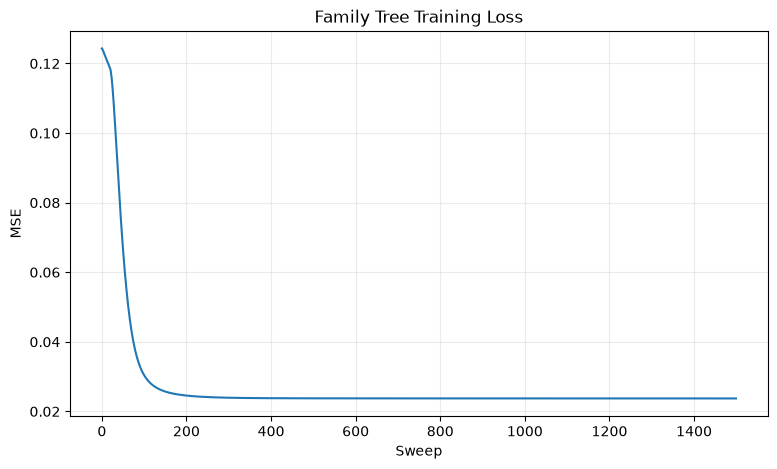

In [11]:

plt.figure(figsize=(9, 5))
plt.plot(loss_history)
plt.xlabel("Sweep")
plt.ylabel("MSE")
plt.title("Family Tree Training Loss")
plt.grid(alpha=0.25)
plt.show()


## 12. Training Performance

In [12]:

train_output, train_cache = model.forward(
    X_person, X_relation
)

train_correct = np.array([
    query_is_correct(train_output[i], Y[i])
    for i in range(len(Y))
])

print(
    f"Paper-style training query accuracy: "
    f"{train_correct.mean():.3f}"
)
print(
    f"Correct training queries: "
    f"{train_correct.sum()} / {len(train_correct)}"
)


Paper-style training query accuracy: 0.000
Correct training queries: 0 / 94



## 13. Test the Four Held-Out Cases

Remember: these four identities are a fixed reproducibility split chosen for this notebook. They are not claimed to be the authors' exact four withheld cases.


In [13]:

test_output, test_cache = model.forward(
    X_person_test, X_relation_test
)

test_results = []

for i, (p1, relation, actual) in enumerate(test_metadata):
    output = test_output[i]

    predicted = [
        people[j]
        for j, value in enumerate(output)
        if value >= 0.5
    ]

    correct = query_is_correct(
        output,
        Y_test[i]
    )

    test_results.append({
        "person1": p1,
        "relation": relation,
        "actual": actual,
        "predicted": predicted,
        "correct": bool(correct)
    })

for result in test_results:
    print(
        f"{result['person1']} + {result['relation']} "
        f"→ actual={result['actual']} | "
        f"predicted={result['predicted']} | "
        f"correct={result['correct']}"
    )

print(
    "\nHeld-out query accuracy:",
    np.mean([r["correct"] for r in test_results])
)


Alfonse + aunt → actual=['Gina'] | predicted=[] | correct=False
Colin + aunt → actual=['Margaret'] | predicted=[] | correct=False
Lucia + son → actual=['Alfonse'] | predicted=[] | correct=False
Victoria + son → actual=['Colin'] | predicted=[] | correct=False

Held-out query accuracy: 0.0



## 14. Inspect a Multi-Answer Query

The paper's Figure 3 uses **Colin + aunt** as an example. Colin has two correct aunts: Margaret and Jennifer.

Because the output is a 24-unit multi-label vector, both people can be activated.


In [14]:

def inspect_query(model, person1, relation, top_k=8):
    Xp = encode_person(person1).reshape(1, -1)
    Xr = encode_relation(relation).reshape(1, -1)

    output, cache = model.forward(Xp, Xr)
    output = output[0]

    ranking = np.argsort(output)[::-1][:top_k]

    print(f"{person1} + {relation}")
    print("-" * 40)

    for idx in ranking:
        print(f"{people[idx]:12s}: {output[idx]:.4f}")

    return output, cache

colin_aunt_output, colin_aunt_cache = inspect_query(
    model, "Colin", "aunt"
)


Colin + aunt
----------------------------------------
Angela      : 0.1275
Jennifer    : 0.1275
Victoria    : 0.1275
Emilio      : 0.1275
Arthur      : 0.1275
Marco       : 0.1275
Lucia       : 0.1275
James       : 0.1275



## 15. Inspect the Learned Person Bottleneck

The paper emphasizes that the six-unit representation of a person can encode useful latent properties such as:

- English vs Italian family
- generation
- family branch

These properties are not explicitly present in the one-hot input representation.


In [15]:

person_representation = train_cache["a_person"]

print("Representation shape:", person_representation.shape)

for i, person in enumerate(people):
    print(
        f"{person:12s}: "
        f"{np.round(person_representation[i], 3)}"
    )


Representation shape: (94, 6)
Christopher : [0.504 0.503 0.504 0.502 0.504 0.503]
Penelope    : [0.504 0.503 0.504 0.502 0.504 0.503]
Andrew      : [0.504 0.503 0.504 0.502 0.504 0.503]
Christine   : [0.504 0.503 0.504 0.502 0.504 0.503]
Margaret    : [0.504 0.503 0.504 0.502 0.504 0.503]
Arthur      : [0.504 0.504 0.503 0.502 0.503 0.502]
Victoria    : [0.504 0.504 0.503 0.502 0.503 0.502]
James       : [0.504 0.504 0.503 0.502 0.503 0.502]
Jennifer    : [0.504 0.504 0.503 0.503 0.502 0.503]
Charles     : [0.504 0.504 0.503 0.503 0.502 0.503]
Colin       : [0.504 0.504 0.503 0.503 0.502 0.503]
Charlotte   : [0.504 0.504 0.503 0.503 0.502 0.503]
Roberto     : [0.504 0.504 0.503 0.503 0.502 0.503]
Maria       : [0.504 0.504 0.503 0.503 0.502 0.503]
Pierro      : [0.504 0.505 0.503 0.503 0.503 0.502]
Francesca   : [0.504 0.505 0.503 0.503 0.503 0.502]
Gina        : [0.504 0.505 0.503 0.503 0.503 0.502]
Emilio      : [0.504 0.505 0.503 0.503 0.503 0.502]
Lucia       : [0.504 0.505 0.503 0

## 16. Visualize the Learned Person Representations

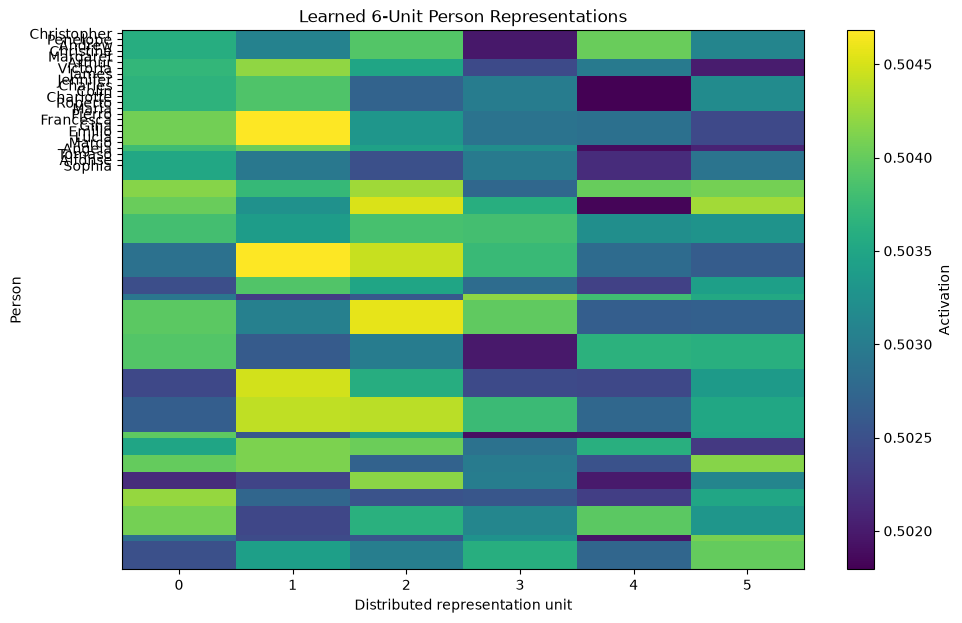

In [16]:

plt.figure(figsize=(11, 7))
plt.imshow(person_representation, aspect="auto")
plt.colorbar(label="Activation")
plt.xlabel("Distributed representation unit")
plt.ylabel("Person")
plt.title("Learned 6-Unit Person Representations")
plt.yticks(np.arange(24), people)
plt.show()



## 17. Compare Corresponding English and Italian People

The two trees are isomorphic. Corresponding people are paired in the same structural positions.

This analysis checks whether their learned six-dimensional representations become similar.


In [17]:

for english, italian in zip(english_people, italian_people):
    e = person_representation[person_to_index[english]]
    i = person_representation[person_to_index[italian]]
    distance = np.linalg.norm(e - i)

    print(
        f"{english:12s} ↔ {italian:12s} | "
        f"distance={distance:.4f}"
    )


Christopher  ↔ Roberto      | distance=0.0028
Penelope     ↔ Maria        | distance=0.0028
Andrew       ↔ Pierro       | distance=0.0024
Christine    ↔ Francesca    | distance=0.0024
Margaret     ↔ Gina         | distance=0.0024
Arthur       ↔ Emilio       | distance=0.0009
Victoria     ↔ Lucia        | distance=0.0009
James        ↔ Marco        | distance=0.0009
Jennifer     ↔ Angela       | distance=0.0014
Charles      ↔ Tomaso       | distance=0.0011
Colin        ↔ Alfonse      | distance=0.0011
Charlotte    ↔ Sophia       | distance=0.0011


## 18. Visualize Person Input → Person Bottleneck Weights

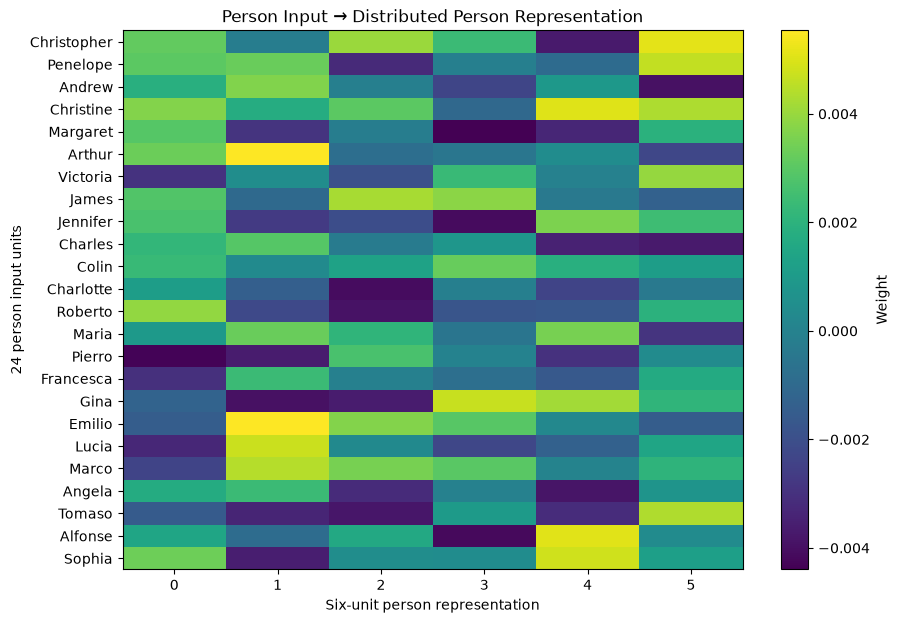

In [18]:

plt.figure(figsize=(10, 7))
plt.imshow(model.W_person, aspect="auto")
plt.colorbar(label="Weight")
plt.xlabel("Six-unit person representation")
plt.ylabel("24 person input units")
plt.title("Person Input → Distributed Person Representation")
plt.yticks(np.arange(24), people)
plt.show()



## 19. Optional Second Random Initialization

The original work used random initial weights. A later description of the experiment reports two historical runs with different initial weights, with one getting all four held-out cases and the other getting three of four.

Because the paper does not publish the exact initial matrices or the exact four withheld cases, this second run is only a **stability experiment for this implementation**.


In [19]:

model2, loss2, accuracy2 = train(
    seed=123,
    epochs=1500,
    print_every=300
)

test_output2, _ = model2.forward(
    X_person_test, X_relation_test
)

test_correct2 = np.array([
    query_is_correct(test_output2[i], Y_test[i])
    for i in range(len(Y_test))
])

print(
    "Second-run held-out query accuracy:",
    test_correct2.mean()
)


Sweep    1 | Loss=0.129337 | training query accuracy=0.000
Sweep  300 | Loss=0.023946 | training query accuracy=0.000
Sweep  600 | Loss=0.023751 | training query accuracy=0.000
Sweep  900 | Loss=0.023738 | training query accuracy=0.000
Sweep 1200 | Loss=0.023731 | training query accuracy=0.000
Sweep 1500 | Loss=0.023727 | training query accuracy=0.000
Second-run held-out query accuracy: 0.0


## 20. Compare Training Curves

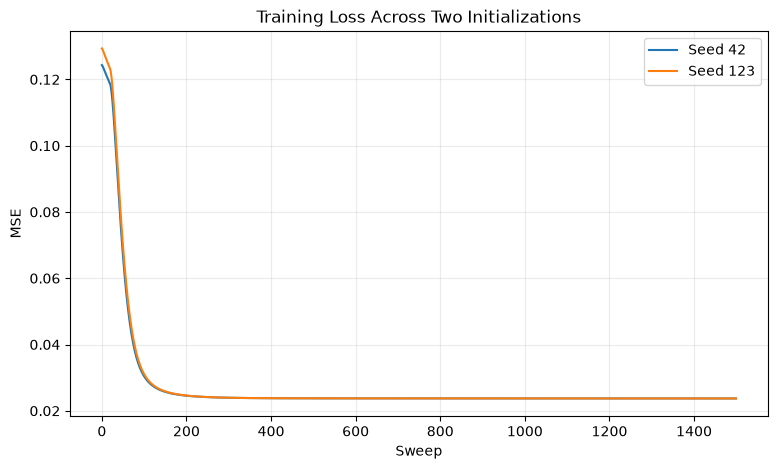

In [20]:

plt.figure(figsize=(9, 5))
plt.plot(loss_history, label="Seed 42")
plt.plot(loss2, label="Seed 123")
plt.xlabel("Sweep")
plt.ylabel("MSE")
plt.title("Training Loss Across Two Initializations")
plt.legend()
plt.grid(alpha=0.25)
plt.show()



## 21. Paper vs Notebook

| Component | Original paper | This notebook |
|---|---:|---:|
| People | 24 | 24 |
| Relationship types | 12 | 12 |
| Possible facts | 104 | 104 |
| Training facts | 100 | 100 |
| Held-out facts | 4 | 4 |
| Person bottleneck | 6 | 6 |
| Relationship bottleneck | 6 | 6 |
| Central layer | 12 | 12 |
| Penultimate layer | 6 | 6 |
| Output | 24 | 24 |
| Sweeps | 1,500 | 1,500 |
| First 20 sweeps | ε=.005, α=.5 | Same |
| Remaining sweeps | ε=.01, α=.9 | Same |
| Weight decay | 0.2% | 0.2% |
| Exact initial weights | Not published | Seeded random initialization |
| Exact held-out identities | Not stated in paper text | Fixed documented split |

### Interpretation

The notebook reproduces the **method and experimental structure**, not the exact historical numerical run. That distinction should be preserved in the final project report.



## 22. Conclusion

This experiment demonstrates the paper's central idea in a structured relational setting.

The network receives localist names and relationship labels, but the hidden layers must compress those inputs into distributed representations before producing the answer. This gives us a concrete way to examine how backpropagation can construct internal features that are not explicitly specified in the input representation.

The most important artifact for the project is therefore not only the final test accuracy, but also the learned six-unit representations and the relationship between those representations and the structure of the two isomorphic family trees.

### Primary source

Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature, 323, 533–536.

### Additional verification sources

Quinlan (1990) reproduces the 104-fact family-tree task and the 100/4 training-test protocol.

Marcus (2001), *The Algebraic Mind*, also describes the 24-person, 12-relation, 104-fact family-tree experiment and the two random-initialization runs.

The uploaded Nature paper remains the primary source for the implementation.
